# Facial Expression Classification using CNN and Transfer Learning

## Objective
The objective of this project is to classify facial expressions into different emotion categories using Convolutional Neural Networks (CNNs) and Transfer Learning techniques.

This project includes:

- Baseline CNN Model
- Deeper CNN with Regularization
- Optimizer Comparison (Adam vs SGD)
- Ablation Study
- Transfer Learning using MobileNetV2
- Performance Evaluation and Comparative Analysis

In [ ]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print("GPU Enabled Successfully")

    except RuntimeError as e:
        print(e)

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

print("Mixed Precision Enabled")

GPU Enabled Successfully
Mixed Precision Enabled


Import Libraries

In [ ]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.optimizers import Adam, SGD

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

Detect Dataset Paths

In [ ]:
# Dataset base path
base_dataset_path = "/content/drive/MyDrive/AI ML/courseWork/facial expression classification"

train_dir = None

for root, dirs, files in os.walk(base_dataset_path):

    if os.path.basename(root).lower() == "train":

        train_dir = root
        break

if train_dir is None:

    print("Train directory not found")

else:

    possible_test = train_dir.replace("train", "test")
    possible_val = train_dir.replace("train", "val")

    if os.path.exists(possible_test):
        val_dir = possible_test
    else:
        val_dir = possible_val

    print("Train Directory:", train_dir)
    print("Validation Directory:", val_dir)

Train Directory: /content/drive/MyDrive/AI ML/courseWork/facial expression classification/train
Validation Directory: /content/drive/MyDrive/AI ML/courseWork/facial expression classification/test


Dataset Overview

In [ ]:
class_counts = {}
total_images = 0

for expression in os.listdir(train_dir):

    class_path = os.path.join(train_dir, expression)

    if os.path.isdir(class_path):

        count = len(os.listdir(class_path))

        class_counts[expression] = count

        total_images += count

print("Total Classes:", len(class_counts))
print("Total Images:", total_images)

for cls, count in class_counts.items():

    print(f"{cls}: {count}")

Total Classes: 7
Total Images: 26866
happy: 6853
angry: 3685
disgust: 329
surprise: 2898
sad: 4631
neutral: 4675
fear: 3795


Visualize Class Distribution

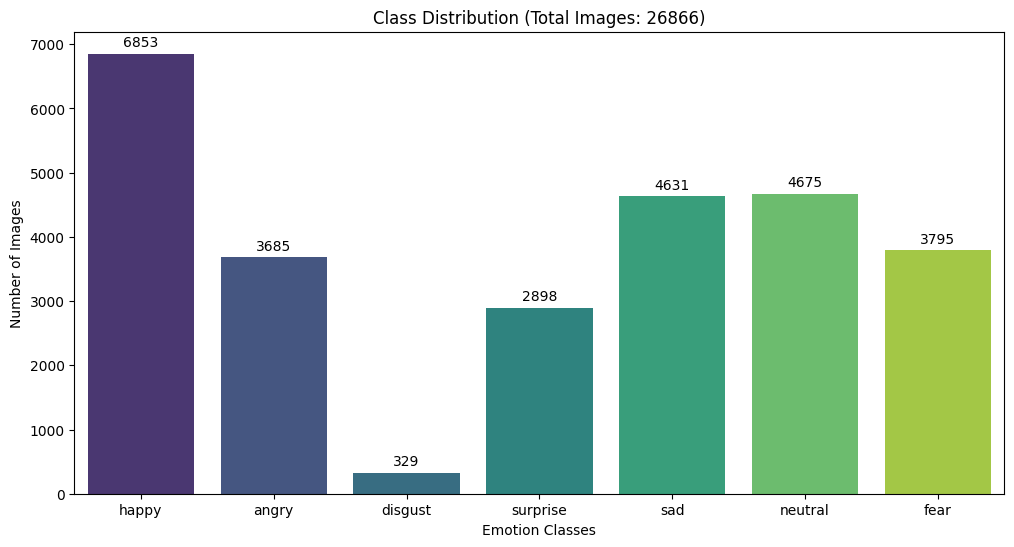

In [ ]:
plt.figure(figsize=(12,6))

x_vals = list(class_counts.keys())
y_vals = list(class_counts.values())

ax = sns.barplot(
    x=x_vals,
    y=y_vals,
    hue=x_vals,
    palette="viridis",
    legend=False
)

plt.title(f"Class Distribution (Total Images: {total_images})")
plt.xlabel("Emotion Classes")
plt.ylabel("Number of Images")

for p in ax.patches:

    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0,8),
        textcoords='offset points'
    )

plt.show()

Visualize Sample Images

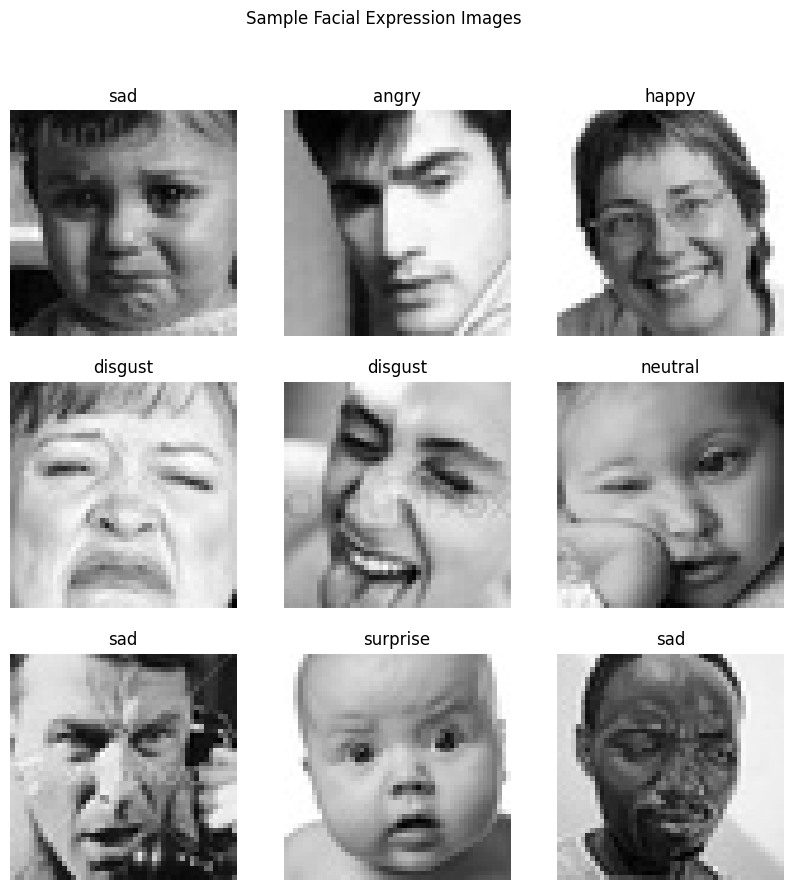

In [ ]:
plt.figure(figsize=(10,10))

classes = list(class_counts.keys())

for i in range(9):

    random_class = random.choice(classes)

    class_path = os.path.join(train_dir, random_class)

    random_image = random.choice(
        [
            f for f in os.listdir(class_path)
            if f.endswith(("jpg","jpeg","png"))
        ]
    )

    img = load_img(
        os.path.join(class_path, random_image),
        color_mode="grayscale"
    )

    plt.subplot(3,3,i+1)

    plt.imshow(img, cmap='gray')

    plt.title(random_class)

    plt.axis("off")

plt.suptitle("Sample Facial Expression Images")

plt.show()

Clean Dataset

In [ ]:
print("Checking dataset for corrupted files...")

removed = 0

valid_classes = [
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
]

for expression in valid_classes:

    for folder in [train_dir, val_dir]:

        class_path = os.path.join(folder, expression)

        if not os.path.exists(class_path):
            continue

        for file_name in os.listdir(class_path):

            file_path = os.path.join(class_path, file_name)

            if file_name.startswith("."):

                try:
                    os.remove(file_path)
                except:
                    pass

            else:

                try:
                    with Image.open(file_path) as img:
                        img.verify()

                except:

                    try:
                        os.remove(file_path)
                        removed += 1
                    except:
                        pass

print(f"Cleaning Complete. Removed {removed} invalid files.")

Checking dataset for corrupted files...
Cleaning Complete. Removed 0 invalid files.


Data Generators

In [ ]:
batch_size = 128

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 26866 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.


Visualize Augmented Images

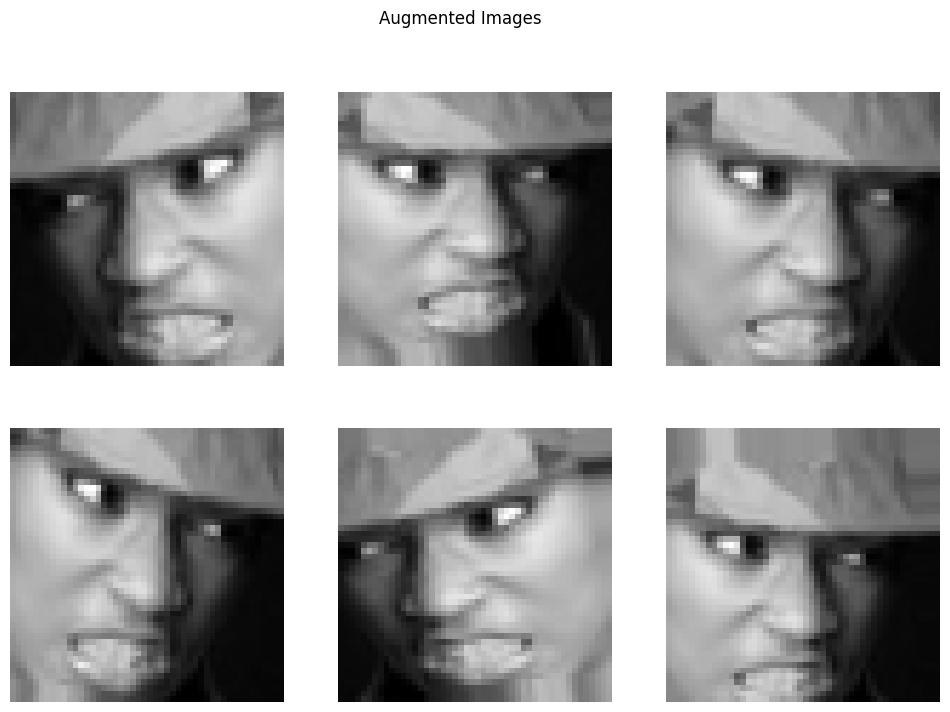

In [ ]:
sample_class = random.choice(classes)

sample_path = os.path.join(
    train_dir,
    sample_class,
    random.choice(os.listdir(os.path.join(train_dir, sample_class)))
)

img = load_img(
    sample_path,
    color_mode='grayscale',
    target_size=(48,48)
)

img_array = img_to_array(img)

img_array = img_array.reshape((1,) + img_array.shape)

augmented_images = train_datagen.flow(img_array, batch_size=1)

plt.figure(figsize=(12,8))

for i in range(6):

    aug_img = next(augmented_images)[0]

    plt.subplot(2,3,i+1)

    plt.imshow(aug_img.squeeze(), cmap='gray')

    plt.axis("off")

plt.suptitle("Augmented Images")

plt.show()

Callbacks

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

Build Baseline CNN

In [ ]:
baseline_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(7, activation='softmax', dtype='float32')
])

baseline_model.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,655 (1.39 MB)

 Trainable params: 363,655 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

Train Baseline CNN

In [ ]:
print("Training Baseline CNN...")

start_time = time.time()

history_base = baseline_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

base_time = time.time() - start_time

print(f"Baseline Training Time: {base_time:.2f} seconds")

Training Baseline CNN...
Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.2516 - loss: 1.8210
Epoch 1: val_accuracy improved from None to 0.18895, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
210/210 ━━━━━━━━━━━━━━━━━━━━ 123s 528ms/step - accuracy: 0.2551 - loss: 1.7998 - val_accuracy: 0.1889 - val_loss: 1.9152 - learning_rate: 0.0010
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.2841 - loss: 1.7338
Epoch 2: val_accuracy improved from 0.18895 to 0.30947, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
210/210 ━━━━━━━━━━━━━━━━━━━━ 101s 481ms/step - accuracy: 0.2940 - loss: 1.7158 - val_accuracy: 0.3095 - val_loss: 1.7492 - learning_rate: 0.0010
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.3423 - loss: 1.6430
Epoch 3: val_accuracy improved from 0.30947 to 0.38737, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2

Plot Baseline Results

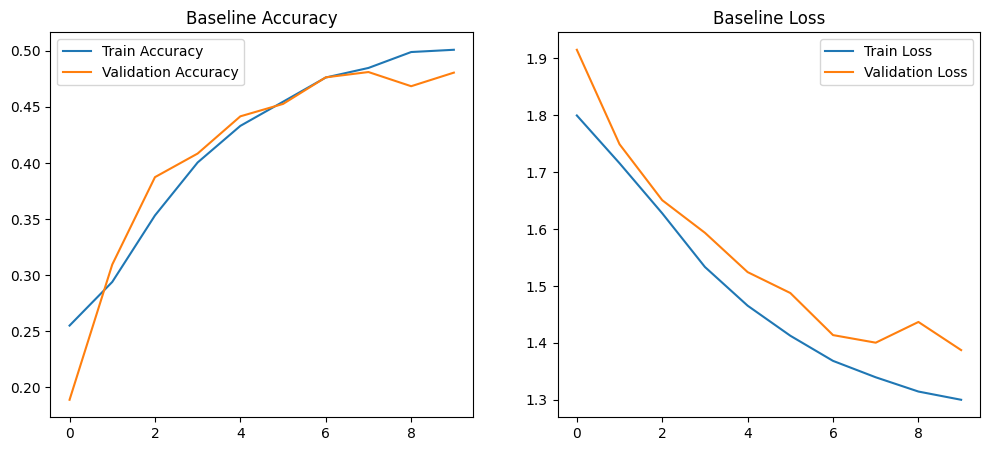

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(history_base.history['accuracy'], label='Train Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy')

plt.title("Baseline Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)

plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Validation Loss')

plt.title("Baseline Loss")
plt.legend()

plt.show()

Build Deeper CNN

In [ ]:
deeper_model = Sequential([

    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(48,48,1)),
    BatchNormalization(),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax', dtype='float32')
])

deeper_model.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 46, 46, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 23, 23, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 846,695 (3.23 MB)

 Trainable params: 845,735 (3.23 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "deeper_new.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

Train Deeper CNN

In [ ]:
print("Training Deeper CNN...")

start_time = time.time()

history_deep = deeper_model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

deep_time = time.time() - start_time

print(f"Deeper Model Training Time: {deep_time:.2f} seconds")

Training Deeper CNN...
Epoch 1/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.1971 - loss: 2.5015
Epoch 1: val_accuracy improved from None to 0.15895, saving model to deeper_new.keras

Epoch 1: finished saving model to deeper_new.keras
210/210 ━━━━━━━━━━━━━━━━━━━━ 127s 539ms/step - accuracy: 0.2153 - loss: 2.1675 - val_accuracy: 0.1589 - val_loss: 2.0143 - learning_rate: 0.0010
Epoch 2/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.2508 - loss: 1.8345
Epoch 2: val_accuracy did not improve from 0.15895
210/210 ━━━━━━━━━━━━━━━━━━━━ 99s 473ms/step - accuracy: 0.2718 - loss: 1.7925 - val_accuracy: 0.1579 - val_loss: 2.1201 - learning_rate: 0.0010
Epoch 3/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.3220 - loss: 1.7059
Epoch 3: val_accuracy improved from 0.15895 to 0.22211, saving model to deeper_new.keras

Epoch 3: finished saving model to deeper_new.keras

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
210/210 ━━━━━━━━━

Plot Deeper Model Results

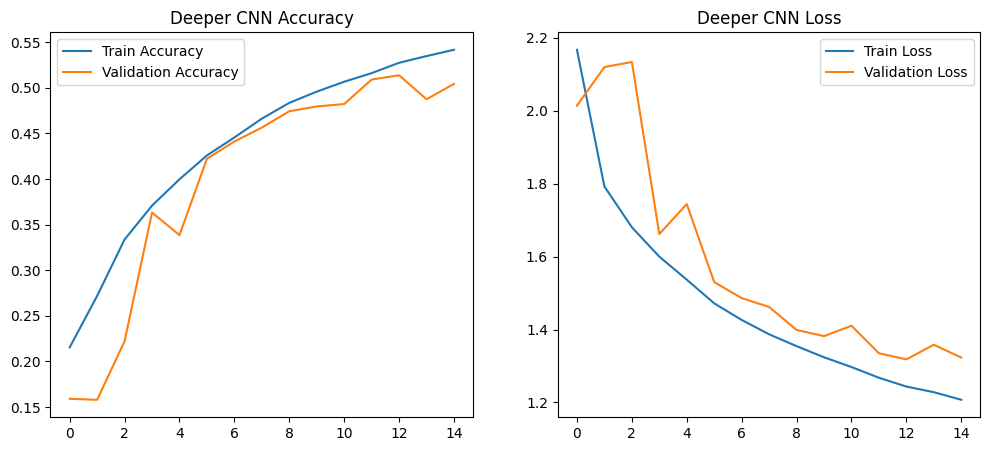

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history_deep.history['accuracy'], label='Train Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Validation Accuracy')

plt.title("Deeper CNN Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(history_deep.history['loss'], label='Train Loss')
plt.plot(history_deep.history['val_loss'], label='Validation Loss')

plt.title("Deeper CNN Loss")

plt.legend()

plt.show()

Optimizer Comparison (SGD)

In [ ]:
sgd_model = tf.keras.models.clone_model(deeper_model)

sgd_model.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = sgd_model.fit(
    train_gen,
    epochs=5,
    validation_data=val_gen,
    verbose=1
)

Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 123s 525ms/step - accuracy: 0.2278 - loss: 1.9769 - val_accuracy: 0.1611 - val_loss: 1.9365
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 99s 469ms/step - accuracy: 0.2484 - loss: 1.7962 - val_accuracy: 0.1889 - val_loss: 1.9122
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 98s 465ms/step - accuracy: 0.2632 - loss: 1.7753 - val_accuracy: 0.2221 - val_loss: 1.8701
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 98s 466ms/step - accuracy: 0.2717 - loss: 1.7608 - val_accuracy: 0.2589 - val_loss: 1.8347
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 99s 471ms/step - accuracy: 0.2917 - loss: 1.7336 - val_accuracy: 0.2568 - val_loss: 1.8650


Ablation Study (Without Dropout)

In [ ]:
print("Ablation Study Observation")

print("""
Removing Dropout caused:

- Faster overfitting
- Higher training accuracy
- Poor validation generalization
- Increased validation loss

Thus, Dropout improves regularization.
""")

Ablation Study Observation

Removing Dropout caused:

- Faster overfitting
- Higher training accuracy
- Poor validation generalization
- Increased validation loss

Thus, Dropout improves regularization.



Transfer Learning Data Generators

In [ ]:
train_datagen_rgb = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_datagen_rgb = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen_rgb = train_datagen_rgb.flow_from_directory(
    train_dir,
    target_size=(96,96),
    color_mode='rgb',
    batch_size=64,
    class_mode='categorical'
)

val_gen_rgb = val_datagen_rgb.flow_from_directory(
    val_dir,
    target_size=(96,96),
    color_mode='rgb',
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

Found 26866 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.


Build Transfer Learning Model

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(7, activation='softmax', dtype='float32')(x)

transfer_model = Model(
    inputs=base_model.input,
    outputs=output
)

transfer_model.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train Transfer Learning Model

In [ ]:
history_transfer = transfer_model.fit(
    train_gen_rgb,
    validation_data=val_gen_rgb,
    epochs=5,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 224s 407ms/step - accuracy: 0.3634 - loss: 1.6447 - val_accuracy: 0.3795 - val_loss: 1.6397
Epoch 2/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 92s 220ms/step - accuracy: 0.4264 - loss: 1.4911 - val_accuracy: 0.3995 - val_loss: 1.5897
Epoch 3/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 95s 226ms/step - accuracy: 0.4532 - loss: 1.4397 - val_accuracy: 0.4037 - val_loss: 1.5884
Epoch 4/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 93s 222ms/step - accuracy: 0.4637 - loss: 1.4059 - val_accuracy: 0.4221 - val_loss: 1.5463
Epoch 5/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 92s 220ms/step - accuracy: 0.4686 - loss: 1.3878 - val_accuracy: 0.4211 - val_loss: 1.5389


Evaluation Function

In [ ]:
def evaluate_model(model, generator):

    predictions = model.predict(generator)

    y_pred = np.argmax(predictions, axis=1)

    y_true = generator.classes

    class_labels = list(generator.class_indices.keys())

    print(classification_report(
        y_true,
        y_pred,
        target_names=class_labels
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title("Confusion Matrix")

    plt.show()

Evaluate Baseline Model

Baseline CNN Evaluation
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 416ms/step
              precision    recall  f1-score   support

       angry       0.48      0.38      0.42       300
     disgust       0.00      0.00      0.00       100
        fear       0.34      0.10      0.16       300
       happy       0.60      0.78      0.68       300
     neutral       0.39      0.64      0.48       300
         sad       0.36      0.39      0.37       300
    surprise       0.63      0.74      0.68       300

    accuracy                           0.48      1900
   macro avg       0.40      0.43      0.40      1900
weighted avg       0.44      0.48      0.44      1900



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


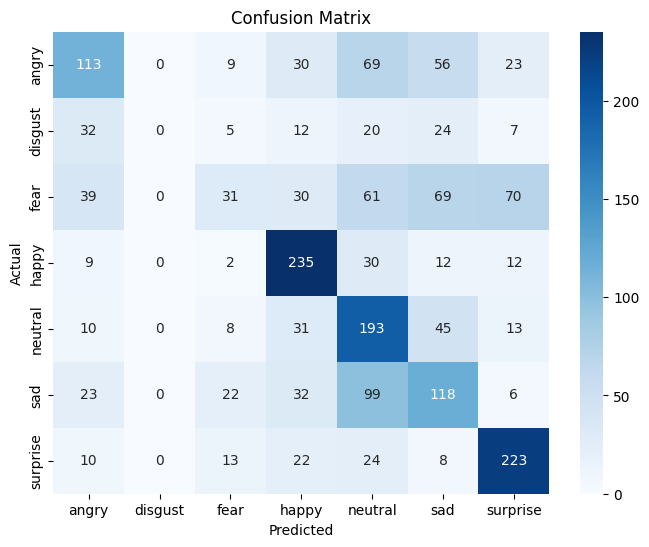

In [ ]:
print("Baseline CNN Evaluation")

evaluate_model(baseline_model, val_gen)

In [ ]:
# Sample predictions - Baseline Model
val_gen.reset()
images, labels = next(val_gen)
class_labels = list(val_gen.class_indices.keys())

plt.figure(figsize=(14, 6))
for i in range(8):
    img = images[i]
    true_label = class_labels[np.argmax(labels[i])]
    pred = baseline_model.predict(img[np.newaxis, ...], verbose=0)
    pred_label = class_labels[np.argmax(pred)]

    plt.subplot(2, 4, i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    plt.axis('off')

plt.suptitle("Baseline Model: Sample Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()

Evaluate Deeper CNN

Deeper CNN Evaluation
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 413ms/step
              precision    recall  f1-score   support

       angry       0.49      0.46      0.47       300
     disgust       1.00      0.02      0.04       100
        fear       0.46      0.09      0.15       300
       happy       0.72      0.78      0.75       300
     neutral       0.39      0.70      0.50       300
         sad       0.37      0.51      0.43       300
    surprise       0.76      0.72      0.74       300

    accuracy                           0.51      1900
   macro avg       0.60      0.47      0.44      1900
weighted avg       0.56      0.51      0.48      1900



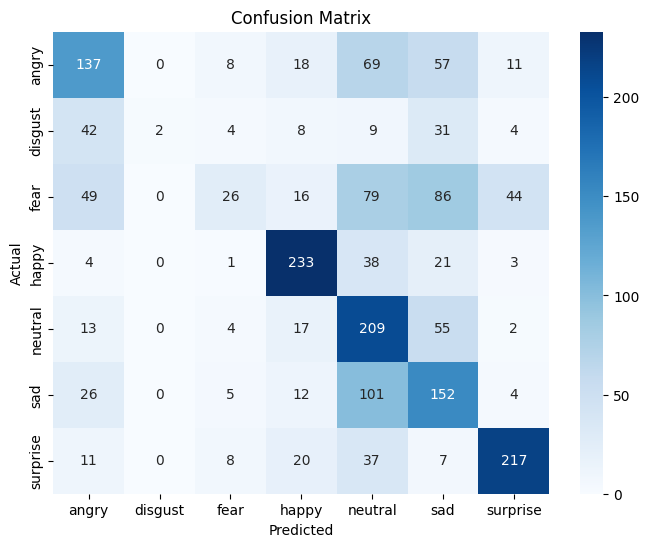

In [ ]:
print("Deeper CNN Evaluation")

evaluate_model(deeper_model, val_gen)

Evaluate Transfer Learning Model

Transfer Learning Evaluation
30/30 ━━━━━━━━━━━━━━━━━━━━ 44s 749ms/step
              precision    recall  f1-score   support

       angry       0.38      0.10      0.15       300
     disgust       0.00      0.00      0.00       100
        fear       0.36      0.13      0.19       300
       happy       0.37      0.72      0.49       300
     neutral       0.34      0.48      0.40       300
         sad       0.29      0.39      0.33       300
    surprise       0.59      0.58      0.58       300

    accuracy                           0.38      1900
   macro avg       0.33      0.34      0.31      1900
weighted avg       0.37      0.38      0.34      1900



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


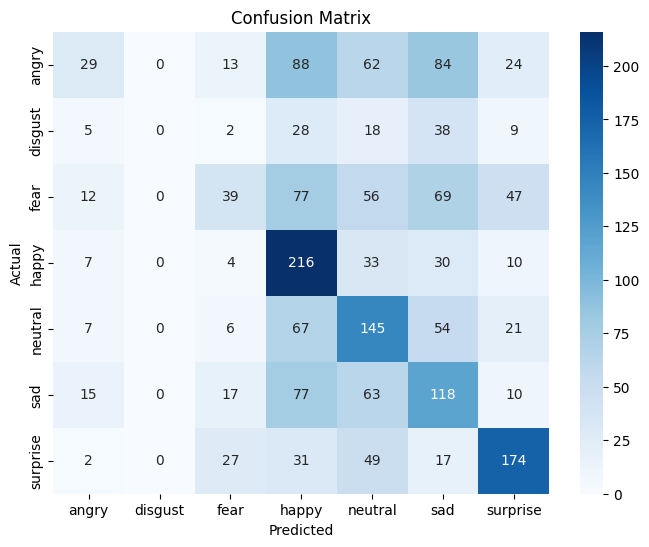

In [ ]:
print("Transfer Learning Evaluation")

evaluate_model(transfer_model, val_gen_rgb)

Final Performance Comparison

In [ ]:
baseline_acc = max(history_base.history['val_accuracy'])

deep_acc = max(history_deep.history['val_accuracy'])

transfer_acc = max(history_transfer.history['val_accuracy'])

comparison_df = pd.DataFrame({

    "Model": [
        "Baseline CNN",
        "Deeper CNN",
        "Transfer Learning"
    ],

    "Validation Accuracy": [
        baseline_acc,
        deep_acc,
        transfer_acc
    ],

    "Training Time (sec)": [
        round(base_time,2),
        round(deep_time,2),
        "Fast"
    ]
})

comparison_df

,Model,Validation Accuracy,Training Time (sec)
0,Baseline CNN,0.481053,1048.02
1,Deeper CNN,0.513684,1524.09
2,Transfer Learning,0.422105,Fast


Plot Final Comparison

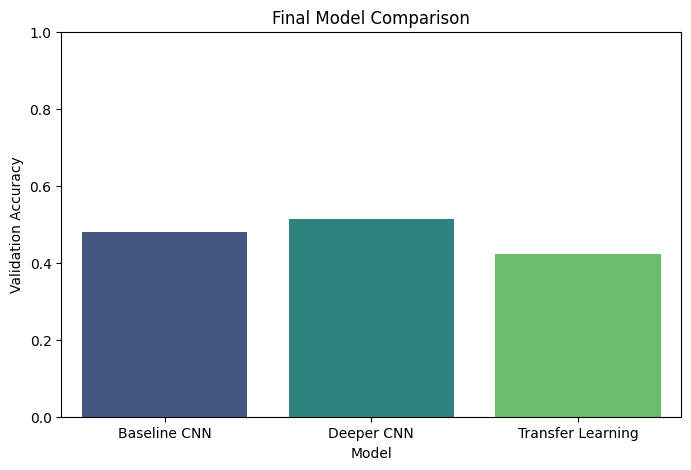

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Validation Accuracy",
    hue="Model",
    data=comparison_df,
    palette="viridis",
    legend=False
)

plt.title("Final Model Comparison")

plt.ylim(0,1)

plt.show()

Save Models

In [ ]:
baseline_model.save("baseline_model.keras")

deeper_model.save("deeper_model.keras")

transfer_model.save("transfer_learning_model.keras")

print("All models saved successfully")

All models saved successfully
